# Quick Learning Curve Sandbox

This notebook keeps the workflow minimal: it reuses `DataPreparation` for preprocessing/poisoning, calls the training utilities from `model.py`, and overlays the validation learning curves for multiple FrogDQ modes (default: `none`, `inertia`, `samplewise`, `dirichlet`, `q`).
Provide the dataset/poisoning parameters in the configuration cell, run the last cell, and you will get an on-the-fly plot plus a short metric summary.
If you plug in a brand-new dataset, make sure it follows the same schema handled in `DataPreparation` (or extend that class with your loader) so the preprocessing and poisoning steps stay compatible.


In [8]:
from typing import Sequence, Tuple, Dict, Optional

import matplotlib.pyplot as plt
import torch

from DataPreparation import DataPreparation
from model import build_model, train, parse_frogdq_mode


def _detect_device() -> torch.device:
    """Pick the best available accelerator for local experiments."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = _detect_device()
print(f"Using device: {DEVICE}")


Using device: mps


In [9]:
def prepare_dataset(
    dataset_name: str,
    *,
    splitting_perc_train_test: float,
    splitting_perc_test_val: float,
    features_percentage: float,
    poisoning_percentage: float,
    random_state: int,
) -> Dict:
    """Helper that wraps DataPreparation so we only need to provide the name."""
    prep = DataPreparation(dataset_name=dataset_name)
    prep.load()
    return prep.run_preprocessing(
        splitting_perc_train_test=splitting_perc_train_test,
        splitting_perc_test_val=splitting_perc_test_val,
        features_percentage=features_percentage,
        poisoning_percentage=poisoning_percentage,
        random_state=random_state,
    )


def plot_learning_curves(mode_histories: Sequence[Tuple[str, dict]], metric: str = "val_bal_acc") -> None:
    """Overlay validation learning curves for each FrogDQ mode."""
    titles = {
        "val_loss": "Validation loss",
        "val_acc": "Validation accuracy",
        "val_bal_acc": "Validation balanced accuracy",
        "val_f1": "Validation F1",
        "val_auc": "Validation AUC",
    }
    ylabel = titles.get(metric, metric.replace("_", " " ).title())

    if not mode_histories:
        print("No histories available for plotting.")
        return

    plt.figure(figsize=(10, 6))
    plotted = False
    for mode_name, history in mode_histories:
        values = history.get(metric, [])
        if not values:
            continue
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=mode_name, linewidth=2.0)
        plotted = True

    if not plotted:
        print(f"Metric '{metric}' not found in the available histories.")
        return

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(f"Validation curve — {ylabel}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_learning_curve_experiment(
    *,
    dataset_name: str,
    poisoning_key: str,
    frogdq_modes: Sequence[str],
    features_percentage: float = 0.2,
    poisoning_percentage: float = 0.2,
    splitting_perc_train_test: float = 0.8,
    splitting_perc_test_val: float = 0.5,
    random_state: int = 42,
    epochs: int = 100,
    batch_size: int = 256,
    lr: float = 1e-3,
    optimizer: str = "sgd",
    model_arch: str = "mlp",
    metric: str = "val_bal_acc",
    show_training_logs: bool = False,
    train_overrides: Optional[Dict] = None,
) -> Dict[str, dict]:
    """
    Run preprocessing once, train over the requested FrogDQ modes, plot the curves,
    and return the raw histories (keyed by canonical mode name).
    """
    data_bundle = prepare_dataset(
        dataset_name,
        splitting_perc_train_test=splitting_perc_train_test,
        splitting_perc_test_val=splitting_perc_test_val,
        features_percentage=features_percentage,
        poisoning_percentage=poisoning_percentage,
        random_state=random_state,
    )

    available_splits = sorted(
        k for k, v in data_bundle.items() if isinstance(v, dict) and 'X_train' in v
    )
    if poisoning_key not in data_bundle:
        raise ValueError(
            f"Poisoning split '{poisoning_key}' not found. Choose among: {available_splits}"
        )

    split = data_bundle[poisoning_key]
    class_count = int(torch.unique(data_bundle['y_train']).numel())
    mode_histories: list[Tuple[str, dict]] = []
    summaries: list[Tuple[str, Optional[float]]] = []
    extra_train_args = dict(train_overrides or {})

    for requested_mode in frogdq_modes:
        modules = parse_frogdq_mode(requested_mode)
        canonical_name = modules.canonical
        active_modules = set(modules.active)
        requested_modules = set(modules.requested)
        use_gate = "inertia" in active_modules

        q_vec = split['q'] if use_gate else None
        r_vec = split.get('r') if "samplewise" in active_modules else None
        gate_init_vector = split['q'].tolist() if "q" in requested_modules else None

        print(f"Training mode: {canonical_name}")
        model = build_model(
            input_dim=split['X_train'].shape[1],
            output_dim=class_count,
            arch=model_arch,
            use_frogdq=use_gate,
            gate_init_vector=gate_init_vector,
            random_state=random_state,
        )

        history = train(
            model=model,
            X_train=split['X_train'],
            y_train=data_bundle['y_train'],
            X_val=split['X_val'],
            y_val=data_bundle['y_val'],
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            optimizer=optimizer,
            frogdq_mode=canonical_name,
            q_vec=q_vec,
            r_vec=r_vec,
            device=DEVICE,
            verbose=show_training_logs,
            random_state=random_state,
            **extra_train_args,
        )

        mode_histories.append((canonical_name, history))
        metric_values = history.get(metric, [])
        summaries.append((canonical_name, metric_values[-1] if metric_values else None))

    plot_learning_curves(mode_histories, metric=metric)

    print(f"\nFinal {metric} per mode:")
    for mode_name, value in summaries:
        if value is None:
            print(f"  - {mode_name}: n/a")
        else:
            print(f"  - {mode_name}: {value:.4f}")

    return {name: history for name, history in mode_histories}


In [19]:
from ucimlrepo import fetch_ucirepo

# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

/Users/mattia.sabella/PhD - PoliMi/Frog-DQ/Repository/FrogDQ.Federated_Proximal_Gating_with_Data_Quality/venv/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [20]:
y.value_counts()

readmitted
NO            54864
>30           35545
<30           11357
Name: count, dtype: int64

In [17]:
# ---------------------------------------------------------------------------
# Adjust these dictionaries to point to your dataset and hyper-parameters
# ---------------------------------------------------------------------------
dataset_config = dict(
    dataset_name="credit_cards",
    poisoning_key="all",  # one of: clean, flipping, noise, nan, all
    features_percentage=0.2,
    poisoning_percentage=0.8,
    splitting_perc_train_test=0.7,
    splitting_perc_test_val=0.5,
    random_state=42,
)

training_config = dict(
    epochs=500,
    batch_size=256,
    lr=0.00015,
    optimizer="sgd",
    model_arch="mlp",
    metric="val_f1",
    show_training_logs=True,
)

# Extra keyword arguments passed straight to model.train (optional)
train_overrides = dict(
    lambda_prox=0.1,
    frog_temp_tau=2.0,
    frog_temp_eta=1.01,
)

frogdq_modes = ["none", "inertia", "samplewise", "dirichlet"]


/Users/mattia.sabella/PhD - PoliMi/Frog-DQ/Repository/FrogDQ.Federated_Proximal_Gating_with_Data_Quality/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/mattia.sabella/PhD - PoliMi/Frog-DQ/Repository/FrogDQ.Federated_Proximal_Gating_with_Data_Quality/data_poisoning.py:286: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.44643330298407885' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_poisoned.loc[instance_idx, feature] = new_value
/Users/mattia.sabella/PhD - PoliMi/Frog-DQ/Repository/FrogDQ.Federated_Proximal_Gating_with_Data_Quality/data_poisoning.py:286: FutureWarning: Setting an item of incompatible dtype is deprecated and 

Training mode: none


2025-11-27 17:32:16.475 | INFO     | model:train:794 - Epoch   5 | mode=none | reg_scale=0.000 | lr=1.50e-04 | train: loss=0.6416, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.6464, bal_acc=0.6385, f1=0.5903, auc=0.6883 | val: loss=0.6502, acc=0.4832, bal_acc=0.5999, f1=0.4750, auc=0.6873
2025-11-27 17:32:18.018 | INFO     | model:train:794 - Epoch  10 | mode=none | reg_scale=0.000 | lr=1.50e-04 | train: loss=0.6296, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.6756, bal_acc=0.6512, f1=0.6112, auc=0.6972 | val: loss=0.6381, acc=0.5261, bal_acc=0.6124, f1=0.5090, auc=0.6968
2025-11-27 17:32:19.572 | INFO     | model:train:794 - Epoch  15 | mode=none | reg_scale=0.000 | lr=1.50e-04 | train: loss=0.6230, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.6958, bal_acc=0.6591, f1=0.6255, auc=0.7020 | val: loss=0.6318, acc=0.5497, bal_acc=0.6214, f1=0.5272, auc

Training mode: inertia


2025-11-27 17:33:16.314 | INFO     | model:train:794 - Epoch   5 | mode=inertia | reg_scale=1.000 | lr=1.50e-04 | train: loss=0.6415, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.6465, bal_acc=0.6386, f1=0.5903, auc=0.6884 | val: loss=0.6500, acc=0.4834, bal_acc=0.6004, f1=0.4753, auc=0.6875
2025-11-27 17:33:18.090 | INFO     | model:train:794 - Epoch  10 | mode=inertia | reg_scale=1.000 | lr=1.50e-04 | train: loss=0.6293, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.6759, bal_acc=0.6513, f1=0.6115, auc=0.6974 | val: loss=0.6378, acc=0.5268, bal_acc=0.6121, f1=0.5094, auc=0.6969
2025-11-27 17:33:19.796 | INFO     | model:train:794 - Epoch  15 | mode=inertia | reg_scale=1.000 | lr=1.50e-04 | train: loss=0.6226, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.6969, bal_acc=0.6595, f1=0.6263, auc=0.7023 | val: loss=0.6315, acc=0.5510, bal_acc=0.6219, f1=0.

Training mode: samplewise


2025-11-27 17:36:17.469 | INFO     | model:train:794 - Epoch   5 | mode=samplewise | reg_scale=1.000 | lr=1.50e-04 | train: loss=0.4440, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.6372, bal_acc=0.6330, f1=0.5830, auc=0.6822 | val: loss=0.6567, acc=0.4677, bal_acc=0.5935, f1=0.4617, auc=0.6786
2025-11-27 17:36:19.633 | INFO     | model:train:794 - Epoch  10 | mode=samplewise | reg_scale=1.000 | lr=1.50e-04 | train: loss=0.4355, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.6546, bal_acc=0.6429, f1=0.5965, auc=0.6928 | val: loss=0.6442, acc=0.5014, bal_acc=0.6066, f1=0.4900, auc=0.6929
2025-11-27 17:36:21.735 | INFO     | model:train:794 - Epoch  15 | mode=samplewise | reg_scale=1.000 | lr=1.50e-04 | train: loss=0.4308, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.6751, bal_acc=0.6514, f1=0.6111, auc=0.6975 | val: loss=0.6371, acc=0.5250, bal_acc=0.61

Training mode: dirichlet


2025-11-27 17:37:46.462 | INFO     | model:train:794 - Epoch   5 | mode=dirichlet | reg_scale=1.000 | lr=1.50e-04 | train: loss=0.6492, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0078, ratio_loss_prior=0.0120 acc=0.6466, bal_acc=0.6386, f1=0.5904, auc=0.6884 | val: loss=0.6499, acc=0.4839, bal_acc=0.6007, f1=0.4757, auc=0.6876
2025-11-27 17:37:48.652 | INFO     | model:train:794 - Epoch  10 | mode=dirichlet | reg_scale=1.000 | lr=1.50e-04 | train: loss=0.6370, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0078, ratio_loss_prior=0.0122 acc=0.6758, bal_acc=0.6512, f1=0.6114, auc=0.6975 | val: loss=0.6378, acc=0.5272, bal_acc=0.6123, f1=0.5098, auc=0.6970
2025-11-27 17:37:50.748 | INFO     | model:train:794 - Epoch  15 | mode=dirichlet | reg_scale=1.000 | lr=1.50e-04 | train: loss=0.6302, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0077, ratio_loss_prior=0.0122 acc=0.6973, bal_acc=0.6598, f1=0.6266, auc=0.7024 | val: loss=0.6314, acc=0.5517, bal_acc=0.6223,

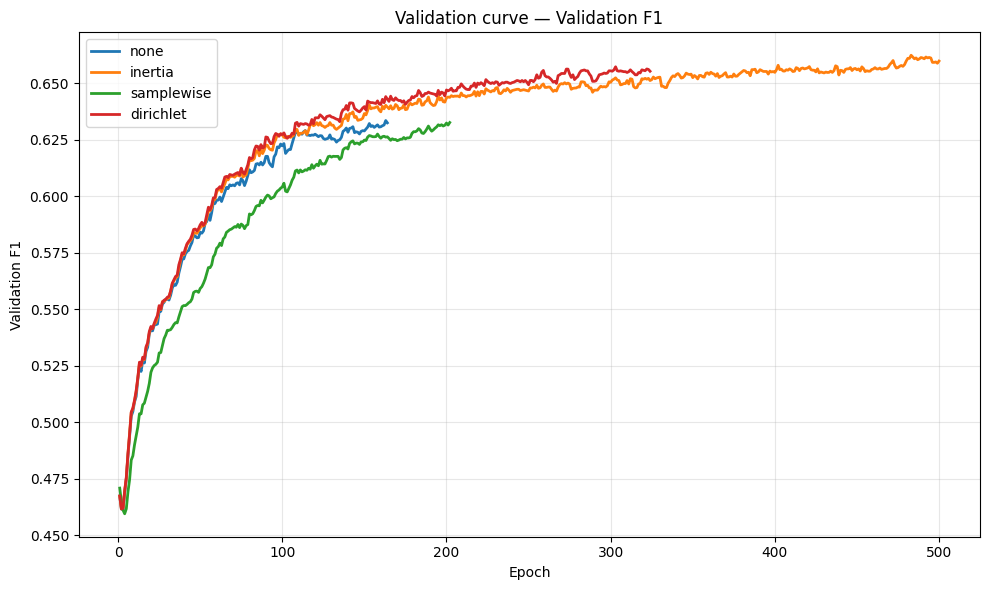


Final val_f1 per mode:
  - none: 0.6325
  - inertia: 0.6598
  - samplewise: 0.6326
  - dirichlet: 0.6553


dict_keys(['none', 'inertia', 'samplewise', 'dirichlet'])

In [15]:
histories = run_learning_curve_experiment(
    frogdq_modes=frogdq_modes,
    train_overrides=train_overrides,
    **dataset_config,
    **training_config,
)

histories.keys()
